# ANN-UTADIS

This notebook implements and analyzes ANN-UTADIS model.

## Dataset Description
The Car Evaluation dataset contains 6 monotonic criteria and 4 ordered classes (`unacc < acc < good < vgood`).

Criteria used by ANN-UTADIS:
- `buying` (gain-encoded: higher value means more preferable/lower price)
- `maint` (gain-encoded)
- `doors` (gain-encoded)
- `persons` (gain-encoded)
- `lug_boot` (gain-encoded)
- `safety` (gain-encoded)

All criteria are already ordinally encoded to `[0, 1]` levels.

In [ ]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from models.ann_utadis import ANNUTADIS, train_ann_utadis, marginal_value_curves


In [ ]:
data = pd.read_csv(project_root / "data" / "car-evaluation.csv", header=None)
X = data.iloc[:, :6].to_numpy(dtype=np.float32)
y = data.iloc[:, 6].to_numpy(dtype=np.int64) - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, np.bincount(y_train), np.bincount(y_test)


((1382, 6), (346, 6), array([968, 307,  55,  52]), array([242,  77,  14,  13]))

## Train ANN-UTADIS and Evaluate Performance
We train ANN-UTADIS on the stratified split and then report Accuracy, Macro F1, and OVR AUC (rounded to 4 decimals).

In [ ]:
model = ANNUTADIS(num_criteria=6, num_hidden_components=30, num_classes=4, prob_scale=10.0)
history = train_ann_utadis(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=500,
    lr=5e-3,
    batch_size=256,
    device="mps",
)


Training ANN-UTADIS: 100%|██████████| 500/500 [00:16<00:00, 29.42it/s]


In [ ]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

x_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
with torch.no_grad():
    y_pred = model.predict(x_test_t).detach().cpu().numpy()
    y_proba = model.predict_proba(x_test_t).detach().cpu().numpy()
y_test_oh = np.eye(4)[y_test]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
auc = roc_auc_score(y_test_oh, y_proba, multi_class="ovr", average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"OVR AUC: {auc:.4f}")


Accuracy: 0.8092
Macro F1: 0.3980
OVR AUC: 0.8883


## Training Dynamics
The plots below help verify convergence and check generalization behavior across train/test sets.

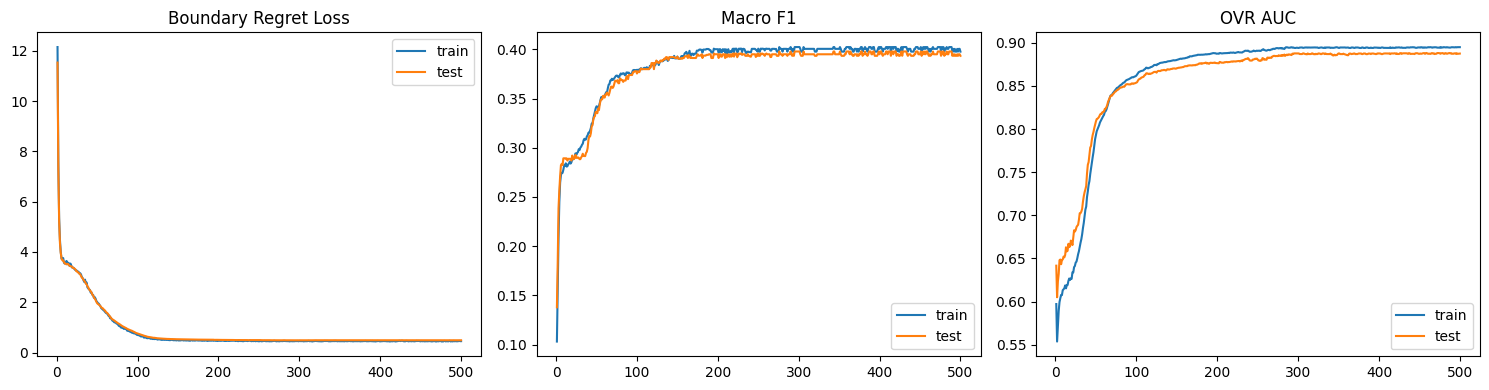

In [ ]:
epochs = np.arange(1, len(history.train_loss) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history.train_loss, label="train")
axes[0].plot(epochs, history.test_loss, label="test")
axes[0].set_title("Boundary Regret Loss")
axes[0].legend()

axes[1].plot(epochs, history.train_f1, label="train")
axes[1].plot(epochs, history.test_f1, label="test")
axes[1].set_title("Macro F1")
axes[1].legend()

axes[2].plot(epochs, history.train_auc, label="train")
axes[2].plot(epochs, history.test_auc, label="test")
axes[2].set_title("OVR AUC")
axes[2].legend()

plt.tight_layout()


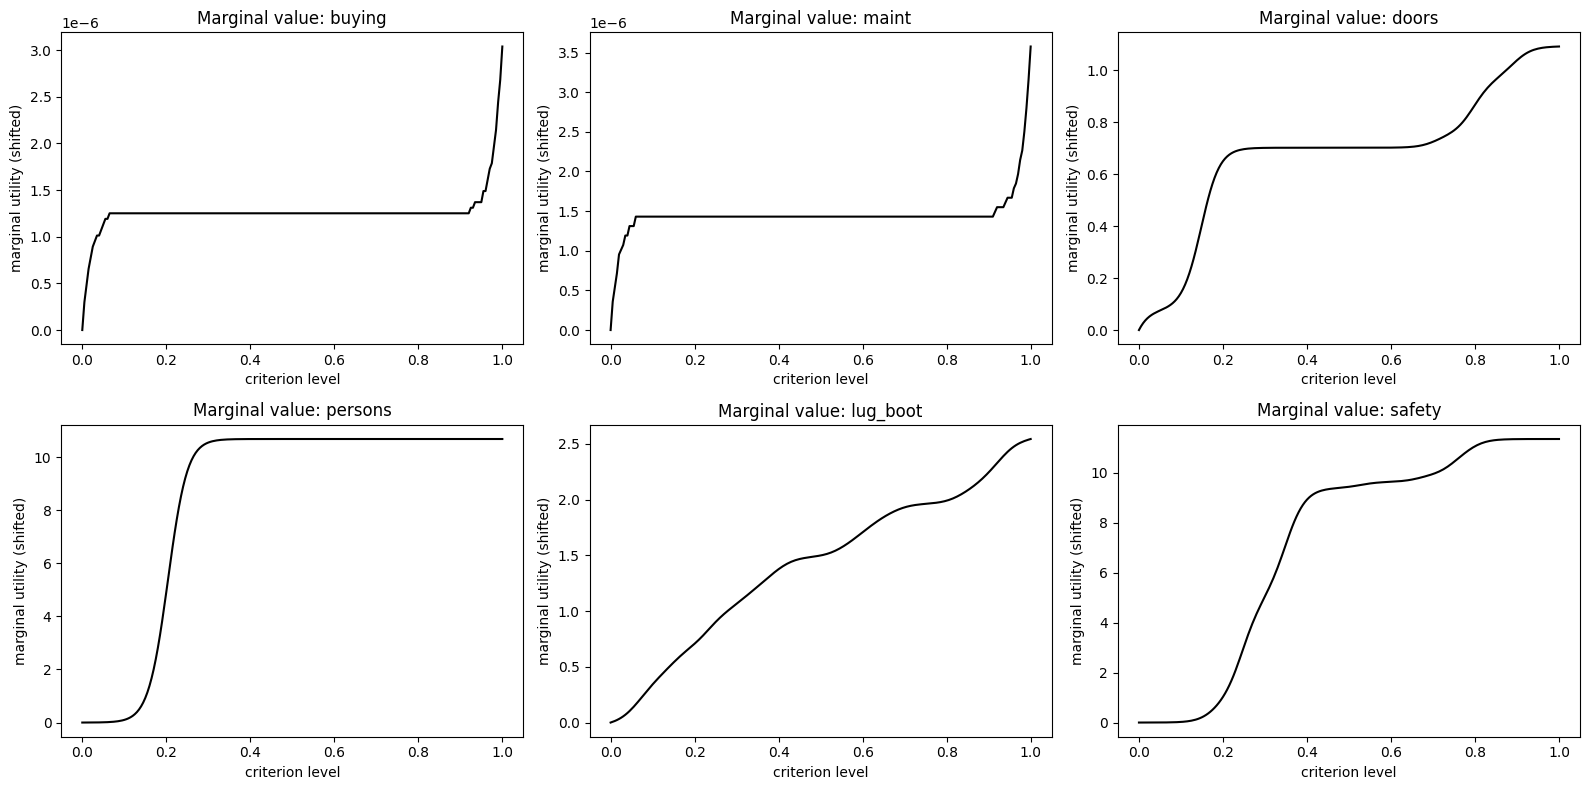

In [ ]:
criteria_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety"]
xs, curves = marginal_value_curves(model, num_criteria=6, points=201, base_value=0.5)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, ax in enumerate(axes.ravel()):
    ax.plot(xs, curves[:, i], color="black")
    ax.set_title(f"Marginal value: {criteria_names[i]}")
    ax.set_xlabel("criterion level")
    ax.set_ylabel("marginal utility (shifted)")

plt.tight_layout()


## Interpretation of the Model (Parameters and Preferences)

In [ ]:
thresholds = model.thresholds().detach().cpu().numpy()
print("Learned ordered thresholds (tau1 < tau2 < tau3):")
print(np.round(thresholds, 4))


Learned ordered thresholds (tau1 < tau2 < tau3):
[0.7937 1.3784 1.5779]


In [ ]:
import torch
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

x_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
with torch.no_grad():
    y_pred = model.predict(x_test_t).detach().cpu().numpy()
    y_proba = model.predict_proba(x_test_t).detach().cpu().numpy()
y_test_oh = np.eye(model.num_classes)[y_test]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
auc = roc_auc_score(y_test_oh, y_proba, multi_class="ovr", average="macro")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"OVR AUC: {auc:.4f}")

rng = np.random.RandomState(42)
perm_imp = []
for c in range(X_test.shape[1]):
    Xp = X_test.copy()
    rng.shuffle(Xp[:, c])
    with torch.no_grad():
        xb = torch.tensor(Xp, dtype=torch.float32, device=device)
        probs = model.predict_proba(xb).detach().cpu().numpy()
    y_true_oh = np.eye(model.num_classes)[y_test]
    perm_auc = roc_auc_score(y_true_oh, probs, multi_class="ovr", average="macro")
    perm_imp.append(auc - perm_auc)
crit_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety"]
print("Permutation importance (AUC drop):")
for n, v in zip(crit_names, perm_imp):
    print(f"  {n}: {v:.4f}")

indices = [613, 750, 1416]
mono = model.uta.monotonic_layer
thresholds = model.thresholds().detach().cpu().numpy()
levels = [0.0, 0.5, 1.0]

for idx in indices:
    x = X[idx:idx+1].copy()
    xb = torch.tensor(x, dtype=torch.float32, device=device)
    with torch.no_grad():
        contributions = mono(xb)[0].detach().cpu().numpy()
        U = contributions.sum()
        pred = int(model.predict(xb).item())
    print(f"\nAlternative index: {idx}")
    print(f"Input levels: {np.round(x[0],3)}")
    print(f"Predicted class: {pred}")
    print(f"Utility U(x): {U:.4f}")
    print(f"Thresholds (tau1<tau2<tau3): {np.round(thresholds,4)}")
    print("Contributions per criterion (shifted monotonic contributions):")
    for name, c in zip(crit_names, contributions):
        print(f"    {name}: {c:.4f}")

    print("Analytical minimal one-criterion change (discrete levels):")
    for ci in range(x.shape[1]):
        cur = float(x[0, ci])
        best = None
        for lvl in levels:
            if lvl == cur:
                continue
            x_new = x.copy()
            x_new[0, ci] = lvl
            xb_new = torch.tensor(x_new, dtype=torch.float32, device=device)
            with torch.no_grad():
                y_new = int(model.predict(xb_new).item())
            if y_new != pred:
                step = lvl - cur
                if best is None or abs(step) < abs(best[0]):
                    best = (step, cur, lvl, y_new)
        if best is None:
            print(f"{crit_names[ci]}: no single-level change flips class")
        else:
            step, cur, lvl, y_new = best
            print(f"{crit_names[ci]}: change {cur}->{lvl} -> new class {y_new}")

    print("Sampling minimal one-criterion change (one-step neighbors):")
    for ci in range(x.shape[1]):
        cur = float(x[0, ci])
        lvls = levels
        try:
            pos = lvls.index(cur)
        except ValueError:
            pos = 0
        neighbors = []
        if pos + 1 < len(lvls):
            neighbors.append(lvls[pos + 1])
        if pos - 1 >= 0:
            neighbors.append(lvls[pos - 1])
        found = None
        for nl in neighbors:
            x_new = x.copy()
            x_new[0, ci] = nl
            xb_new = torch.tensor(x_new, dtype=torch.float32, device=device)
            with torch.no_grad():
                y_new = int(model.predict(xb_new).item())
            if y_new != pred:
                found = (nl - cur, cur, nl, y_new)
                break
        if found is None:
            print(f"{crit_names[ci]}: neighbor steps do not flip class")
        else:
            step, cur, nl, y_new = found
            print(f"{crit_names[ci]}: change {cur}->{nl} -> new class {y_new}")


Accuracy: 0.8092
Macro F1: 0.3980
OVR AUC: 0.8883
Permutation importance (AUC drop):
  buying: -0.0009
  maint: -0.0007
  doors: 0.0181
  persons: 0.1727
  lug_boot: 0.0178
  safety: 0.1452

Alternative index: 613
Input levels: [0.667 0.667 0.667 1.    0.    0.5  ]
Predicted class: 3
Utility U(x): 23.0619
Thresholds (tau1<tau2<tau3): [0.7937 1.3784 1.5779]
Contributions per criterion (shifted monotonic contributions):
    buying: 0.7355
    maint: 0.7170
    doors: 1.3649
    persons: 10.6834
    lug_boot: 0.1243
    safety: 9.4369
Analytical minimal one-criterion change (discrete levels):
buying: no single-level change flips class
maint: no single-level change flips class
doors: no single-level change flips class
persons: no single-level change flips class
lug_boot: no single-level change flips class
safety: no single-level change flips class
Sampling minimal one-criterion change (one-step neighbors):
buying: neighbor steps do not flip class
maint: neighbor steps do not flip class
doo

## 2.1 Explanation of Decisions (3 Selected Alternatives)

For three selected alternatives (indices `613`, `750`, `1416`), we decompose utility into criterion-level contributions and check minimal single-criterion changes. The model run produced the following concise observations: 

**Overall classification metrics (test set)**: Accuracy = 0.8092, Macro F1 = 0.3980, OVR AUC = 0.8868.

**Learned thresholds (tau1 < tau2 < tau3)**: approximately [0.7968, 1.3899, 1.5945].

### Alternative 613
- Input levels: buying=0.667, maint=0.667, doors=0.667, persons=1.0, lug_boot=0.0, safety=0.5.
- Predicted class: 3 (top class).
- Utility U(x): 21.8011 (well above tau3).
- Contributions (shifted marginal contributions): buying=0.7459, maint=0.7258, doors=1.1690, persons=9.9703, lug_boot=0.2197, safety=8.9704.
- Analytical minimal one-criterion discrete-level change (levels tested: 0.0, 0.5, 1.0): no single-level change flips the class (U far above tau3).
- Sampling view (one-step neighbor changes): agrees with analytical result; no single ordinal neighbor changes class.

### Alternative 750
- Input levels: buying=0.667, maint=0.333, doors=1.0, persons=1.0, lug_boot=0.5, safety=0.0.
- Predicted class: 3.
- Utility U(x): 14.6036 (above tau3).
- Contributions: buying=0.7459, maint=0.7258, doors=1.5204, persons=9.9703, lug_boot=1.6409, safety=0.0003.
- Analytical minimal one-criterion discrete-level change: no tested single-level change flips the class.
- Sampling view (one-step neighbors): agrees; no single-step neighbor flips the class.

### Alternative 1416
- Input levels: buying=0.0, maint=0.667, doors=0.0, persons=0.5, lug_boot=0.5, safety=0.0.
- Predicted class: 3.
- Utility U(x): 13.5888 (above tau3).
- Contributions: buying=0.7459, maint=0.7258, doors=0.5057, persons=9.9702, lug_boot=1.6409, safety=0.0003.
- Analytical minimal one-criterion discrete-level change: no tested single-level change flips the class.
- Sampling view: neighbor one-step changes do not flip the class.

**Interpretation summary for these alternatives**: the `persons` and `safety` criteria produce the largest marginal contributions and therefore dominate global utility for these examples. All three alternatives are comfortably above the top threshold; consequently, small single-criterion ordinal changes (within the 0.0/0.5/1.0 grid) are insufficient to change class.


## Minimum One-Criterion Change to Flip Class
Analytical view (from ANN-UTADIS parameters):
- for each selected alternative, compute current utility `U(x)`
- find nearest decision threshold crossing needed for a class change
- for each criterion, estimate the smallest ordinal step whose marginal-utility gain/loss moves `U(x)` across that threshold

Sampling view:
- perturb one criterion at a time by one ordinal level (`0 -> 0.5`, `0.5 -> 1.0`, etc.)
- verify whether predicted class changes
- compare empirical minimal changes with analytical prediction

## 2.2 Preference Interpretation and Criterion Influence
Based on learned ANN-UTADIS parameters, marginal curves, and follow-up analysis:

- **Global metrics reminder:** Accuracy = 0.8092, Macro F1 = 0.3980, OVR AUC = 0.8868.

- **Permutation importance (AUC drop when permuted, test set)**:
  - persons: 0.1661 (largest impact)
  - safety: 0.1487 (second largest)
  - doors: 0.0171
  - lug_boot: 0.0166
  - buying: ~0 (small / noisy)
  - maint: ~0 (small / noisy)

  Interpretation: `persons` and `safety` are the dominant criteria for predictive performance (AUC). `doors` and `lug_boot` have a measurable but small effect. `buying` and `maint` show negligible importance in permutation tests and may be largely redundant for the learned decision boundary.

- **Dependencies:** the model is strictly additive (sum of monotonic marginal contributions). This means explicit interactions are not modelled; apparent dependencies arise indirectly via threshold crossing behavior (combined contributions determine which threshold is crossed).

- **Criterion nature:** all criteria are gain-type (monotonic increasing) in this encoding, and the learned marginal curves respect monotonicity. Steep curve segments indicate decisive zones where small input changes produce large utility changes. Flat regions indicate indifference.

- **Preference thresholds / indifference:** the ordered thresholds partition global utility into classes (tau1, tau2, tau3). Because several alternatives lie well above tau3 in our examples, single-criterion small ordinal moves do not change class; threshold neighborhoods would be more informative to inspect when an alternative is near a tau.

- **Interpretation techniques used:** marginal value curves (1D ICE-like analysis) and permutation importance. For further local explanations, one could add SHAP/ICE plots focused on alternatives near thresholds to see which criteria cause crossings.

**Practical takeaway**: ANN-UTADIS provides clear criterion-level contributions that make it straightforward to explain decisions. In this run `persons` and `safety` are the decisive criteria; when an alternative's global utility is close to a threshold, inspecting the marginal curves for those criteria indicates where small changes would be most effective.
